In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("expense_classifier.csv")
print(df)


               Description  Amount       Category
0       Pizza from Dominos     450           Food
1    Burger from McDonalds     320           Food
2      Lunch at restaurant     600           Food
3       Street food snacks     120           Food
4           Coffee at cafe     180           Food
..                     ...     ...            ...
115      Streaming service     799  Entertainment
116  Mobile games purchase     350  Entertainment
117              Live show    2000  Entertainment
118  Weekend entertainment    1500  Entertainment
119         Club entry fee    1000  Entertainment

[120 rows x 3 columns]


In [3]:
df.describe()

,Amount
count,120.000000
mean,3612.841667
std,6154.753618
min,40.000000
25%,399.750000
50%,1200.000000
75%,2825.000000
max,30000.000000


In [5]:
df.isnull().sum()

Description    0
Amount         0
Category       0
dtype: int64

In [7]:
df.dtypes

Description    object
Amount          int64
Category       object
dtype: object

In [9]:
df.drop_duplicates()

,Description,Amount,Category
0,Pizza from Dominos,450,Food
1,Burger from McDonalds,320,Food
2,Lunch at restaurant,600,Food
3,Street food snacks,120,Food
4,Coffee at cafe,180,Food
...,...,...,...
115,Streaming service,799,Entertainment
116,Mobile games purchase,350,Entertainment
117,Live show,2000,Entertainment
118,Weekend entertainment,1500,Entertainment


In [11]:
df["Category"].value_counts()

Category
Food             20
Travel           20
Rent             20
Shopping         20
Utilities        20
Entertainment    20
Name: count, dtype: int64

In [20]:
# Encode Category Labels
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Category_Label"]=le.fit_transform(df["Category"])
df[["Category", "Category_Label"]].head()
                                      

,Category,Category_Label
0,Food,1
1,Food,1
2,Food,1
3,Food,1
4,Food,1


In [22]:
# Prepare Input Features
df["Desc_Length"]=df["Description"].apply(len)
x=df[["Amount","Desc_Length"]].values
y=df["Category_Label"].values


In [26]:
# Train–Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
# Convert to PyTorch Tensors
import torch
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
y_test=torch.tensor(y_test,dtype=torch.long)



In [65]:
# Build PyTorch Neural Network
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch. optim as optim

In [67]:
# Define the Neural Network
class ExpenseClassifier (nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(2,16)
        self.fc2=nn.Linear(16,16)
        self.fc3=nn.Linear(16,6)
    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x
        
       

Model=ExpenseClassifier()

In [69]:
# Define Loss & Optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(Model.parameters(),lr=0.01)

In [77]:
# Training Loop
epochs=100
for epoch in range(epochs):
    y_pred=Model(X_train)
    loss=loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

if(epoch+1)%10==0:
 print(f"Epoch:{epoch+1}/eopchs,Loss:{loss.item():.4f}")

Epoch:100/eopchs,Loss:1.7898


In [81]:
# Evaluate Accuracy
with torch.no_grad():
    y_test_pred=Model(X_test)
    predicated=torch.argmax(y_test_pred,dim=1)
    accuracy=(predicated ==y_test).sum().item()/len(y_test)
    print(f"Test_accuracy:{ accuracy*100:.2f}%")
    

Test_accuracy:12.50%


In [91]:
# Make Predictions
new_data=torch.tensor([[350,len("Lunch at cafe")]],dtype=torch.float32)
output=Model(new_data)
predicated_class=torch.argmax(output,dim=1)
category_name=le.inverse_transform(predicated_class.numpy())
print("Predicated_class:",category_name[0])


Predicated_class: Entertainment


In [117]:
Model.eval()
with torch.no_grad():
    output=Model(X_test)
    y_pred=torch.argmax(output,dim=1)
    

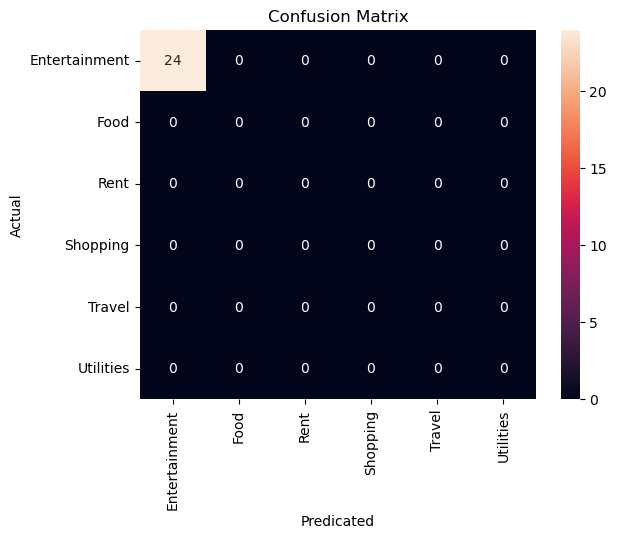

In [125]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test.detach().numpy(),y_pred.detach().numpy(),labels=range(len(le.classes_)))
plt.figure()
sns.heatmap(cm,annot=True,fmt='d',xticklabels=le.classes_,yticklabels=le.classes_)

plt.xlabel("Predicated")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
          
plt.show()


                


In [137]:
print(classification_report(
                         y_test.detach().numpy(),
                            y_pred.detach().numpy(),
                            labels=range(len(le.classes_)),
                            target_names=le.classes_,
      zero_division=0
)
     )
      

               precision    recall  f1-score   support

Entertainment       1.00      1.00      1.00        24
         Food       0.00      0.00      0.00         0
         Rent       0.00      0.00      0.00         0
     Shopping       0.00      0.00      0.00         0
       Travel       0.00      0.00      0.00         0
    Utilities       0.00      0.00      0.00         0

     accuracy                           1.00        24
    macro avg       0.17      0.17      0.17        24
 weighted avg       1.00      1.00      1.00        24



In [143]:
torch.save(Model.state_dict(),"expense_classifier_model.pth")

In [145]:
loaded_model=ExpenseClassifier()
loaded_model.load_state_dict(torch.load("expense_classifier_model.pth"))
loaded_model

ExpenseClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=6, bias=True)
)

In [147]:
new_data=torch.tensor([[1200,len("Electricity bill")]],dtype=torch.float32)
output=loaded_model(new_data)
predicated_class=torch.argmax(output,dim=1)
category_name=le.inverse_transform(predicated_class.numpy())
print("Predicated_class:",category_name[0])

Predicated_class: Entertainment


In [149]:
new_data=torch.tensor([[450,len("Pizza from Dominos")]],dtype=torch.float32)
output=loaded_model(new_data)
predicated_class=torch.argmax(output,dim=1)
category_name=le.inverse_transform(predicated_class.numpy())
print("Predicated_class:",category_name[0])

Predicated_class: Entertainment
